In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

PORTFOLIO_VALUE = 100_000_000

project_root = Path.cwd().parent
portfolio_path = project_root / "config" / "portfolio.csv"

portfolio = pd.read_csv(portfolio_path)
portfolio

,ticker,instrument_name,asset_class,target_weight,currency,primary_risk_factor
0,SPY,SPDR S&P 500 ETF,Equity,0.20,USD,US Equity
1,QQQ,Invesco QQQ Trust,Equity,0.10,USD,US Technology
2,IWM,iShares Russell 2000 ETF,Equity,0.05,USD,US Small Cap
3,XLF,Financial Select Sector SPDR,Equity,0.05,USD,US Financials
4,TLT,iShares 20+ Year Treasury Bond ETF,Rates,0.12,USD,Long Treasury
5,IEF,iShares 7-10 Year Treasury Bond ETF,Rates,0.08,USD,Intermediate Treasury
6,SHY,iShares 1-3 Year Treasury Bond ETF,Rates,0.05,USD,Short Treasury
7,LQD,iShares Investment Grade Corporate Bond ETF,Credit,0.10,USD,Investment Grade Credit
8,HYG,iShares High Yield Corporate Bond ETF,Credit,0.08,USD,High Yield Credit
9,GLD,SPDR Gold Shares,Commodity,0.07,USD,Gold


In [2]:
required_columns = {'ticker', 'instrument_name', 'asset_class','target_weight','currency','primary_risk_factor'}

#check if any columns are missing

missing_columns = required_columns - set(portfolio.columns)  # converting it to a set for subraction purposes
if missing_columns:
     raise ValueError(f"Missing columns: {missing_columns}")

#check if there are any duplicate tickers
if portfolio["ticker"].duplicated().any():
    raise ValueError("Portfolio contains duplicate tickers.")

#check for missing values
if portfolio.isna().any().any():
    raise ValueError("Portfolio contains missing values.")

#check if there are negative values in target weight
if (portfolio['target_weight'] <= 0).any():
    raise ValueError("target weight cannot be negative or zero.")

#check if the target weights add upto one 
WEIGHT_TOLERANCE = 1e-8
total_weight = portfolio["target_weight"].sum()

if not np.isclose(
    total_weight,
    1.0,
    atol=WEIGHT_TOLERANCE,
    rtol=0.0,
):
    raise ValueError(
        f"Target weights must sum to 1. "
        f"Current total: {total_weight:.10f}"
    )






getting data using yf 

In [3]:
import yfinance as yf

START_DATE = "2015-01-01"
END_DATE = "2026-08-12"

tickers = portfolio['ticker'].tolist()

raw_data = yf.download(
    tickers=tickers,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    actions=False,
    progress=False,
)

raw_data.head()

Price            Close                                               \
Ticker             GLD        HYG        IEF         IWM        LQD   
Date                                                                  
2015-01-02  114.080002  48.336552  82.037582  102.543121  80.124245   
2015-01-05  115.800003  47.888813  82.538208  101.172211  80.451920   
2015-01-06  117.120003  47.705379  83.092651   99.421906  80.779549   
2015-01-07  116.430000  48.002075  83.077255  100.646271  80.886543   
2015-01-08  115.940002  48.363525  82.738396  102.353424  80.625771   

Price                                                                ...  \
Ticker            QQQ        SHY         SPY        TLT         USO  ...   
Date                                                                 ...   
2015-01-02  94.561172  68.281914  169.687836  92.287491  159.119995  ...   
2015-01-05  93.174065  68.281914  166.623337  93.737206  150.320007  ...   
2015-01-06  91.924751  68.314240  165.053909  95.426064  144.399994  ...   
2015-01-07  93.109779  68.346535  167.110596  95.237633  146.960007  ...   
2015-01-08  94.891823  68.338448  170.076111  93.976418  148.399994  ...   

Price        Volume                                                     \
Ticker          IEF       IWM        LQD       QQQ      SHY        SPY   
Date                                                                     
2015-01-02  2028600  46133100  2523600.0  31314600  1735400  121465900   
2015-01-05  1521700  51141900  3218800.0  36521300  1214300  169632600   
2015-01-06  1890200  67446000  5313400.0  66205500   959400  209151400   
2015-01-07  1558000  32252100  1636600.0  37577400   768800  125346700   
2015-01-08  1671000  28361700  2156900.0  40212600   862500  147217800   

Price                                             
Ticker           TLT      USO      UUP       XLF  
Date                                              
2015-01-02   9432000  2638313  1887600  40511471  
2015-01-05   9789500  3937438  2855500  50770502  
2015-01-06  18331300  5279375  2262700  57454463  
2015-01-07   9762900  3916575  2384600  36287049  
2015-01-08   8055300  3338188  1685500  37995923  

[5 rows x 60 columns]

Cleaning the data before finding returns

In [4]:
prices = raw_data['Close'].copy()
prices  = prices.reindex(columns=tickers)
for ticker in prices.columns:                      # trying to figure out how many prices are missing before we calculate returns we use a for and if  
    missing_count = prices[ticker].isna().sum()    # sstatment to return dates of when the data is missing

    if missing_count > 0:
        missing_dates = prices.index[
            prices[ticker].isna()
        ]

        print(f"{ticker}: {missing_count} missing price(s)")
        print(missing_dates)
        print()            


LQD: 3 missing price(s)
DatetimeIndex(['2026-07-21', '2026-07-22', '2026-07-31'], dtype='datetime64[ns]', name='Date', freq=None)



since we have only 6 missing days of data for over 11 years of market data we can just drop these rows.

calculating returns

In [5]:
returns = prices.pct_change(fill_method = None)
#print(returns.isna().sum())  #used to see how many na rows are there in each ticker
returns = returns.dropna()
print(returns)

Ticker           SPY       QQQ       IWM       XLF       TLT       IEF  \
Date                                                                     
2015-01-05 -0.018060 -0.014669 -0.013369 -0.021027  0.015709  0.006102   
2015-01-06 -0.009419 -0.013408 -0.017300 -0.015283  0.018017  0.006717   
2015-01-07  0.012461  0.012891  0.012315  0.010487 -0.001975 -0.000185   
2015-01-08  0.017746  0.019139  0.016962  0.014944 -0.013243 -0.004079   
2015-01-09 -0.008014 -0.006582 -0.009603 -0.013497  0.010953  0.004933   
...              ...       ...       ...       ...       ...       ...   
2026-08-05 -0.001997 -0.009049 -0.006430  0.002073  0.002173  0.000643   
2026-08-06 -0.001598 -0.003694 -0.005071 -0.003276 -0.005783 -0.003858   
2026-08-07  0.006115  0.011726  0.011098 -0.003633  0.002908  0.002367   
2026-08-10 -0.000297 -0.002987 -0.005239  0.003646 -0.008458 -0.004401   
2026-08-11 -0.003195 -0.003357  0.003367 -0.000173  0.001584  0.001186   

Ticker           SHY       LQD       

In [6]:
portfolio["target_market_value"] = (
    portfolio["target_weight"] * PORTFOLIO_VALUE
)

position_values = portfolio.set_index("ticker")[
    "target_market_value"
]

missing_exposures = set(returns.columns) - set(position_values.index)
missing_returns = set(position_values.index) - set(returns.columns)

if missing_exposures:
    raise ValueError(
        f"Returns exist without portfolio exposures: {missing_exposures}"
    )

if missing_returns:
    raise ValueError(
        f"Portfolio positions exist without returns: {missing_returns}"
    )

position_values = position_values.reindex(returns.columns)

position_pnl = returns * position_values
position_pnl.head()

Ticker,SPY,QQQ,IWM,XLF,TLT,IEF,SHY,LQD,HYG,GLD,USO,UUP
Date,,,,,,,,,,,,
2015-01-05,-361192.526128,-146688.943534,-66845.568315,-105135.124042,188504.159865,48819.148075,0.000000,40895.844571,-74103.531514,105540.045158,-276520.489662,10330.329979
2015-01-06,-188380.273790,-134083.809628,-86501.281517,-76416.064414,216203.334391,53739.316397,2367.079571,40723.588842,-30643.237308,79792.725564,-196913.688774,10308.560087
2015-01-07,249213.897455,128912.840084,61574.218881,52434.270277,-23695.511999,-1482.308523,2363.725871,13245.262037,49754.675456,-41239.899049,88643.106842,18518.922186
2015-01-08,354916.470047,191391.652877,84809.566592,74718.324304,-158913.888158,-32630.789940,-591.628986,-32239.318745,60239.094888,-29459.632718,48992.484922,20500.182166
2015-01-09,-160280.162367,-65823.469541,-48014.381393,-67484.637399,131432.574502,39461.904249,4137.985546,26538.210813,40156.463753,79696.374583,-72775.892593,-22458.167881


In [7]:
portfolio_pnl = position_pnl.sum(axis=1)
portfolio_returns = portfolio_pnl/100000000
portfolio_returns .head()

Date
2015-01-05   -0.006364
2015-01-06   -0.003098
2015-01-07    0.005982
2015-01-08    0.005817
2015-01-09   -0.001154
dtype: float64

historical var and es calculation

In [8]:
historical_var = np.percentile(portfolio_returns,1)
#tail_returns  = []
#for daily_returns in portfolio_returns:
#   if daily_returns <= historical_var:
#        tail_returns.append(daily_returns)
#historical_es = np.mean(tail_returns)
tail = portfolio_returns <= historical_var
tail_returns = portfolio_returns[tail]
historical_es = tail_returns.mean()
print(f"Historcial var : {historical_var}")
print(f"Historcial es : {historical_es}")
len(portfolio_returns)
len(tail_returns)
tail_returns.max()
historical_breach_rate = len(tail_returns)/len(portfolio_returns)
print(historical_breach_rate)






Historcial var : -0.015159461483852676
Historcial es : -0.02432018470788631
0.010302197802197802


next we calculate rollling historical var 

In [9]:
window_size = 252

forecast_dates = []
var_cutoffs = []
actual_returns = []
breach_results = []

for forecast_index in range(window_size, len(portfolio_returns)):
    historical_window = portfolio_returns.iloc[
        forecast_index - window_size : forecast_index
    ]

    var_cutoff = np.percentile(historical_window, 1)
    actual_return = portfolio_returns.iloc[forecast_index]
    forecast_date = portfolio_returns.index[forecast_index]

    breach = actual_return <= var_cutoff

    forecast_dates.append(forecast_date)
    var_cutoffs.append(var_cutoff)
    actual_returns.append(actual_return)
    breach_results.append(breach)

backtest_results = pd.DataFrame({
    "date": forecast_dates,
    "var_cutoff": var_cutoffs,
    "actual_return": actual_returns,
    "breach": breach_results,
})

backtest_results = backtest_results.set_index("date")
backtest_results.head()

number_of_breaches = backtest_results["breach"].sum()
number_of_forecasts = len(backtest_results)
rolling_breach_rate = number_of_breaches / number_of_forecasts

print(rolling_breach_rate)

0.013533834586466165


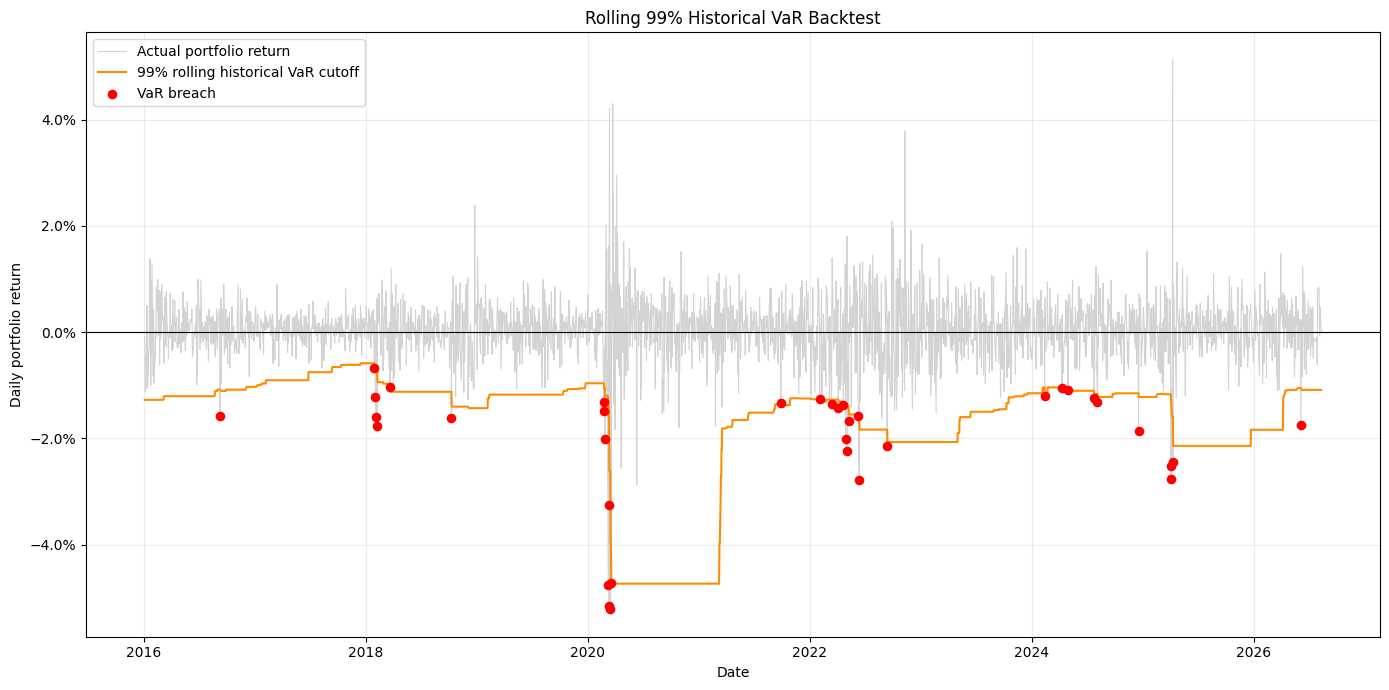

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

breach_days = backtest_results[
    backtest_results["breach"]
]

plt.figure(figsize=(14, 7))

plt.plot(
    backtest_results.index,
    backtest_results["actual_return"],
    color="lightgray",
    linewidth=0.8,
    label="Actual portfolio return",
)

plt.plot(
    backtest_results.index,
    backtest_results["var_cutoff"],
    color="darkorange",
    linewidth=1.5,
    label="99% rolling historical VaR cutoff",
)

plt.scatter(
    breach_days.index,
    breach_days["actual_return"],
    color="red",
    s=35,
    label="VaR breach",
    zorder=3,
)

plt.axhline(
    y=0,
    color="black",
    linewidth=0.8,
)

plt.title("Rolling 99% Historical VaR Backtest")
plt.xlabel("Date")
plt.ylabel("Daily portfolio return")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

EMWA VARIANCE 

In [ ]:
decay = 0.94
window_size = 252

initial_variance = portfolio_returns.iloc[:window_size].var()
ewma_variance = initial_variance

forecast_dates = []
ewma_volatilities = []
ewma_var_cutoffs = []
actual_returns = []
breach_results = []

for forecast_index in range(window_size, len(portfolio_returns)):
    ewma_volatility = np.sqrt(ewma_variance)
    ewma_var_cutoff = -2.326 * ewma_volatility

    actual_return = portfolio_returns.iloc[forecast_index]
    forecast_date = portfolio_returns.index[forecast_index]

    breach = actual_return <= ewma_var_cutoff

    forecast_dates.append(forecast_date)
    ewma_volatilities.append(ewma_volatility)
    ewma_var_cutoffs.append(ewma_var_cutoff)
    actual_returns.append(actual_return)
    breach_results.append(breach)

    ewma_variance = (
        decay * ewma_variance
        + (1 - decay) * actual_return ** 2
    )


number_of_forecasts = len(breach_results)
number_of_breaches = sum(breach_results)
ewma_breach_rate = number_of_breaches / number_of_forecasts

print(f"Number of forecasts: {number_of_forecasts}")
print(f"Number of EWMA VaR breaches: {number_of_breaches}")
print(f"Observed EWMA breach rate: {ewma_breach_rate:.2%}")
     

Number of forecasts: 2660
Number of EWMA VaR breaches: 60
Observed EWMA breach rate: 2.26%
